# RNN -Sentimental Analysis System for IMDb 

## Project Objective

Develop a sentiment analysis system using a Recurrent Neural Network (RNN) that reads IMDb movie reviews and classifies them as:

* Positive 😊
* Negative 😞

The model learns the sequential relationship between words in a review and predicts its sentiment.

## Dataset:

The IMDb Movie Reviews dataset contains 50,000 labeled movie reviews:

25,000 training reviews

25,000 test reviews

* 50% positive
* 50% negative
 
Each review is associated with a binary sentiment label.

In [1]:
# import libraries

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Load Dataset

VOCAB_SIZE = 10000
MAX_LENGTH = 250

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [3]:
# Padding

x_train = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

x_test = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (25000, 250)
Testing shape: (25000, 250)


## Build RNN Model

In [4]:


from tensorflow.keras.layers import LSTM

model = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.build(input_shape=(None, 200))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
# Train the RNN

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 226ms/step - accuracy: 0.5095 - loss: 0.6930 - val_accuracy: 0.5146 - val_loss: 0.6849
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 197ms/step - accuracy: 0.5745 - loss: 0.6623 - val_accuracy: 0.5594 - val_loss: 0.6615
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 193ms/step - accuracy: 0.6172 - loss: 0.5941 - val_accuracy: 0.5972 - val_loss: 0.6327
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 194ms/step - accuracy: 0.6880 - loss: 0.5219 - val_accuracy: 0.7806 - val_loss: 0.5316
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 194ms/step - accuracy: 0.8633 - loss: 0.3549 - val_accuracy: 0.8216 - val_loss: 0.4276


### Accuracy Graph

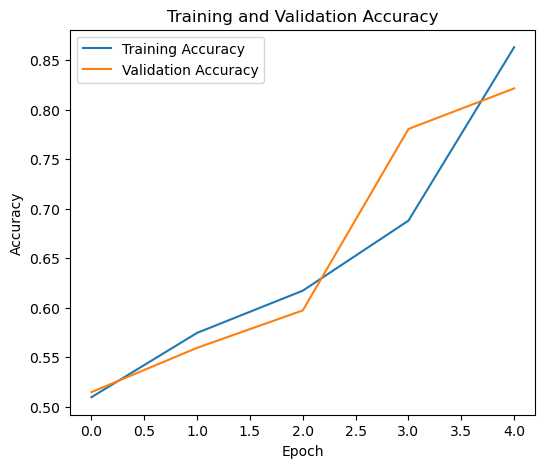

In [7]:
plt.figure(figsize=(6, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

### Loss Graph

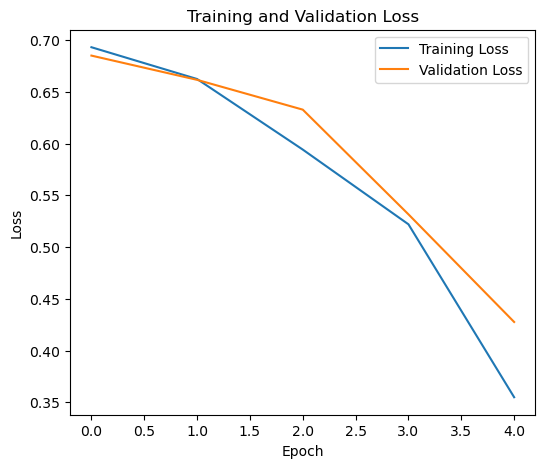

In [8]:
plt.figure(figsize=(6, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

## Evaluate the model

In [9]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.4356607496738434
Test Accuracy: 0.8146399855613708


## Prediction

In [10]:
y_probability = model.predict(x_test)

y_pred = (y_probability >= 0.5).astype(int).flatten()

782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step


## Classification Metrics

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.81464
Precision: 0.8076501877346683
Recall   : 0.826
F1 Score : 0.8167220376522702


## Classification Report

In [12]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative","Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.82      0.80      0.81     12500
    Positive       0.81      0.83      0.82     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000



## Confusion Matrix

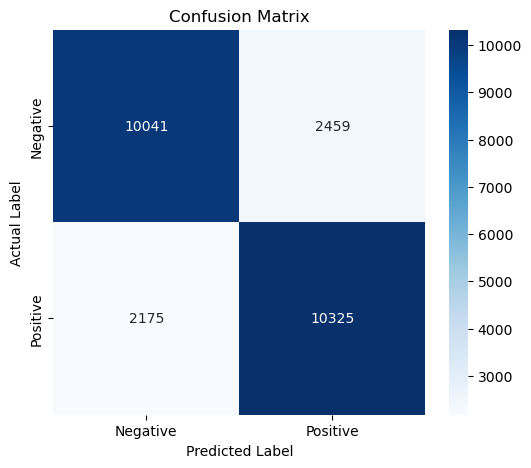

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

### Test  model with new review

In [14]:
word_index = imdb.get_word_index()

def encode_review(review):
    encoded = [1]

    for word in review.lower().split():
        index = word_index.get(word, 2) + 3
        encoded.append(index if index < VOCAB_SIZE else 2)

    return pad_sequences(
        [encoded],
        maxlen=MAX_LENGTH,
        padding='post',
        truncating='post'
    )

### Predit new review

In [15]:
def predict_sentiment(review):
    x = encode_review(review)
    prob = model.predict(x, verbose=0)[0][0]

    return "Positive" if prob >= 0.5 else "Negative"

In [16]:
# test

review = "This movie was amazing and I really enjoyed it."

print("Sentiment:", predict_sentiment(review))

Sentiment: Positive


In [17]:
review = "The movie was boring and disappointing."

print("Sentiment:", predict_sentiment(review))

Sentiment: Negative


## Evaluation metrics

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_prob = model.predict(x_test)
y_pred = (y_prob >= 0.5).astype(int).flatten()

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step
Accuracy : 0.81464
Precision: 0.8076501877346683
Recall   : 0.826
F1 Score : 0.8167220376522702


## ConClusion

In this project, an LSTM-based RNN model was developed to classify IMDb movie reviews as Positive or Negative. The reviews were preprocessed, converted into numerical sequences, and padded to a fixed length. The LSTM model learned the relationships between words and achieved 80% test accuracy. The model was evaluated using accuracy, precision, recall, F1-score, and confusion matrix. Overall, the model was able to classify unseen movie reviews effectively.